In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 783.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.0 MB/s eta 0:00:00


In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Set parameters
data_dir = "/content/drive/MyDrive/Dataset"
img_size = (224, 224)
batch_size = 32

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:82: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# Load dataset with split
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # training 80%, keeping the 20% for validation
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int"  # for multi-class classification
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # using the 20% for val
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int"
)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)

# Improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 22036 files belonging to 4 classes.
Using 17629 files for training.
Found 22036 files belonging to 4 classes.
Using 4407 files for validation.
Class names: ['Benign', 'Early Pre-B-ALL', 'Pre-B-ALL', 'Pro B-ALL']


In [ ]:
for images, labels in train_ds.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)
    print("Sample labels:", labels[:10].numpy())  # first 10 labels


Images batch shape: (32, 224, 224, 3)
Labels batch shape: (32,)
Sample labels: [3 3 0 0 1 0 2 2 0 3]


In [ ]:
for images, labels in train_ds.take(1):
    print("Label dtype:", labels.dtype)
    print("Unique labels:", tf.unique(labels).y.numpy() if len(labels.shape)==1 else "One-hot encoded")


Label dtype: <dtype: 'int32'>
Unique labels: [2 3 1 0]


Pre-Processing and Data augmentation is already applied

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# the CNN model
model = tf.keras.Sequential([
    keras.Input(shape=(img_size[0], img_size[1], 3)),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    GlobalAveragePooling2D(),
    #Flatten(),
    Dense(256, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,           # stop if val_loss doesn’t improve for 8 epochs
    restore_best_weights=True
)

# Reduce learning rate when plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,           # reduce LR by 20%
    patience=3,           # wait 3 epochs before reducing LR
    min_lr=1e-6
)


In [ ]:
# Train the model
history = model.fit(train_ds, validation_data=val_ds, epochs= 20,callbacks=[early_stopping, reduce_lr],
    verbose=1)

Epoch 1/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 441s 792ms/step - accuracy: 0.5289 - loss: 1.8379 - val_accuracy: 0.2764 - val_loss: 4.1139 - learning_rate: 1.0000e-04
Epoch 2/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 362s 657ms/step - accuracy: 0.8022 - loss: 1.2010 - val_accuracy: 0.4336 - val_loss: 3.1095 - learning_rate: 1.0000e-04
Epoch 3/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 361s 656ms/step - accuracy: 0.8827 - loss: 0.9823 - val_accuracy: 0.7034 - val_loss: 1.7376 - learning_rate: 1.0000e-04
Epoch 4/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 357s 648ms/step - accuracy: 0.9153 - loss: 0.8629 - val_accuracy: 0.6660 - val_loss: 2.0774 - learning_rate: 1.0000e-04
Epoch 5/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 361s 655ms/step - accuracy: 0.9371 - loss: 0.7759 - val_accuracy: 0.8963 - val_loss: 0.9026 - learning_rate: 1.0000e-04
Epoch 6/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 365s 662ms/step - accuracy: 0.9480 - loss: 0.7160 - val_accuracy: 0.8836 - val_loss: 0.8764 - learning_rate: 1.0000e-04
Epoch 7/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Save the entire model
import os
os.makedirs('/content/drive/MyDrive/modelscnn1', exist_ok=True)
model.save("efficientnet_b3_full.keras")

In [ ]:
import os
os.makedirs('/content/drive/MyDrive/modelscnn2', exist_ok=True)
# for fast api
save_path = '/content/drive/MyDrive/modelscnn2/my_cnn_model.h5'
model.save('my_cnn_model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


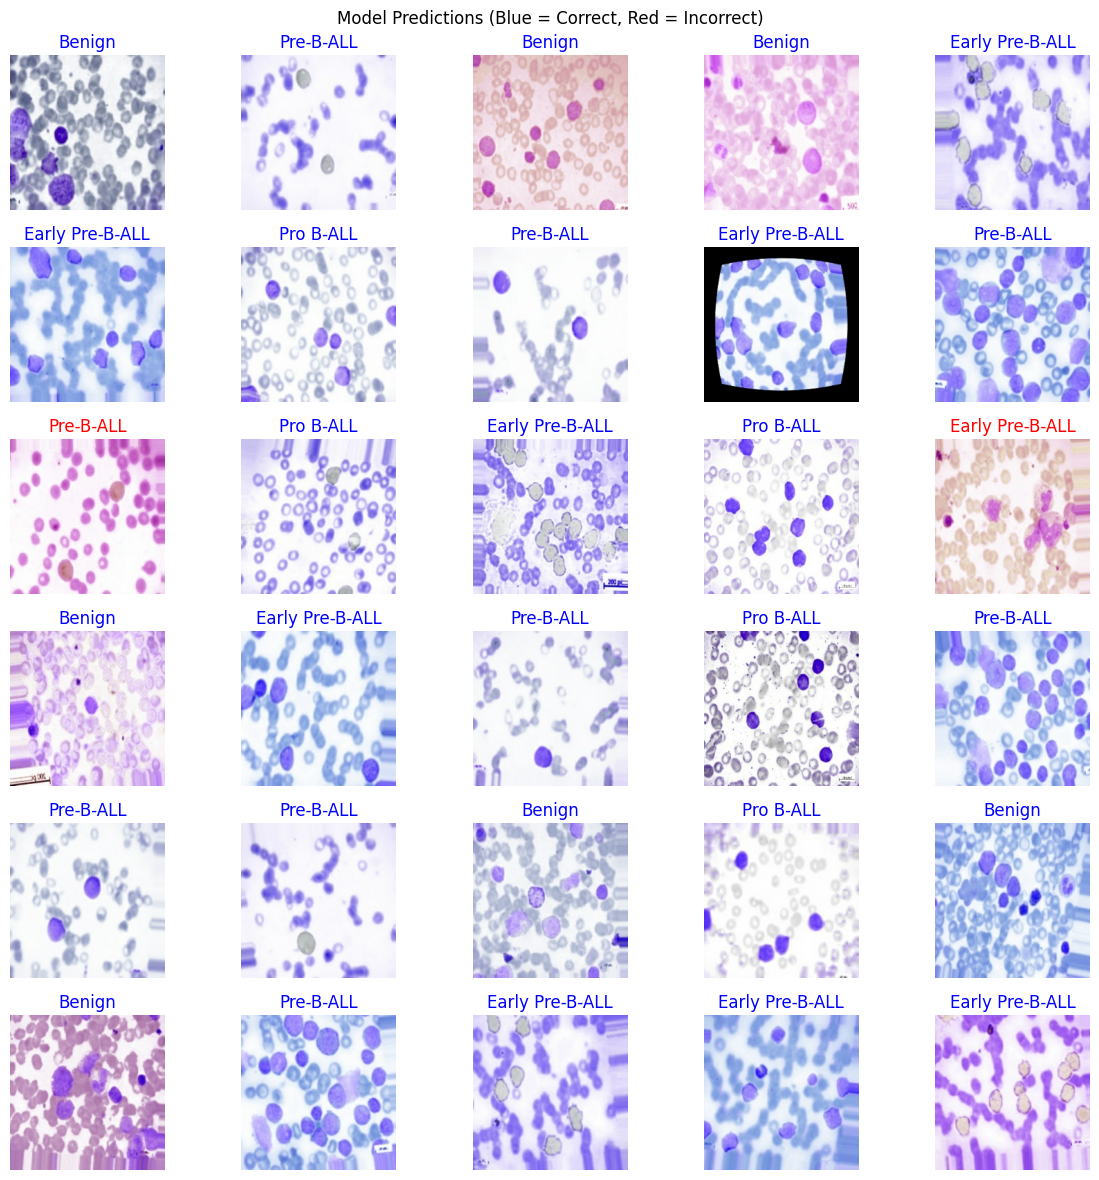

In [ ]:
# Prediction visualization
image_batch, label_batch = next(iter(train_ds.take(1)))
predicted_batch = model.predict(image_batch)
predicted_ids = np.argmax(predicted_batch, axis=-1)
predicted_class_names = [class_names[i] for i in predicted_ids]

# Plot predictions
plt.figure(figsize=(12, 12))
for n in range(min(30, len(image_batch))):
    plt.subplot(6, 5, n + 1)
    plt.imshow(image_batch[n].numpy().astype("uint8"))
    color = "blue" if predicted_ids[n] == label_batch[n].numpy() else "red"
    plt.title(predicted_class_names[n], color=color)
    plt.axis('off')
plt.suptitle("Model Predictions (Blue = Correct, Red = Incorrect)")
plt.tight_layout()
plt.show()


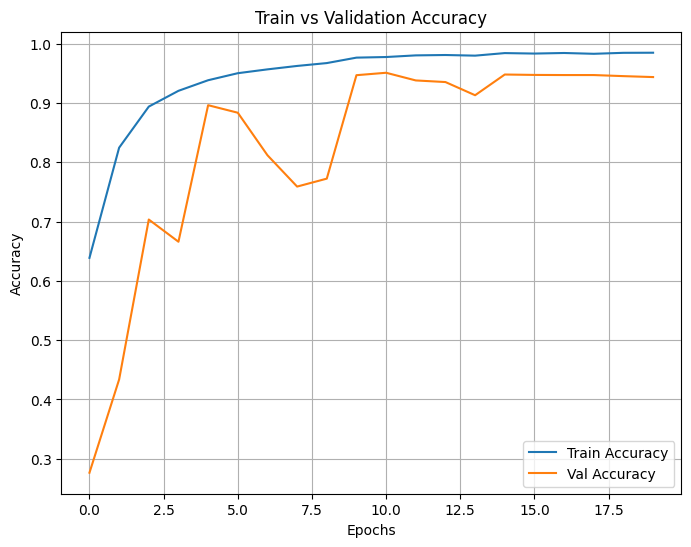

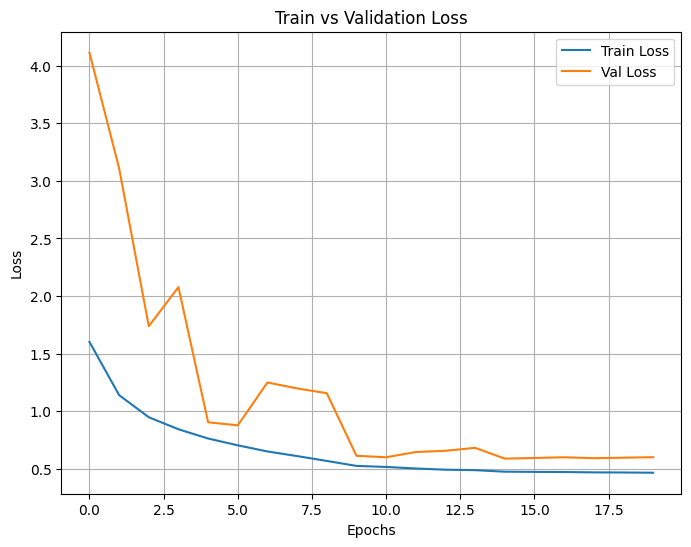

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("train_vs_val_accuracy.png")
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig("Train vs Validation Loss.png")
plt.show()


/tmp/ipython-input-4155074125.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


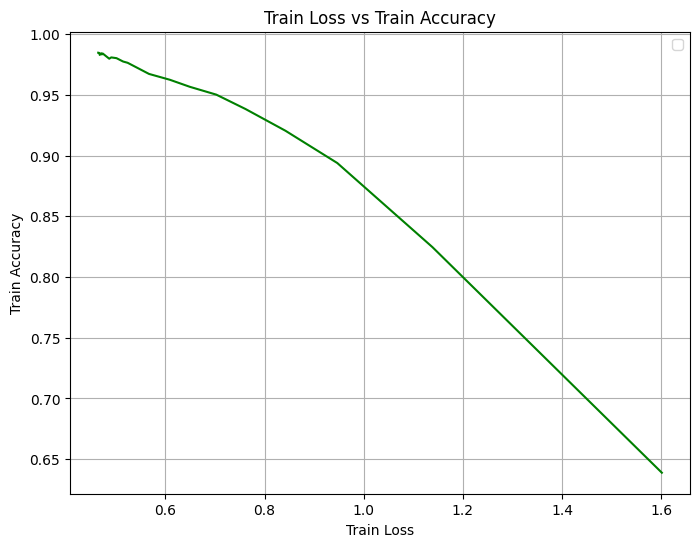

/tmp/ipython-input-4155074125.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


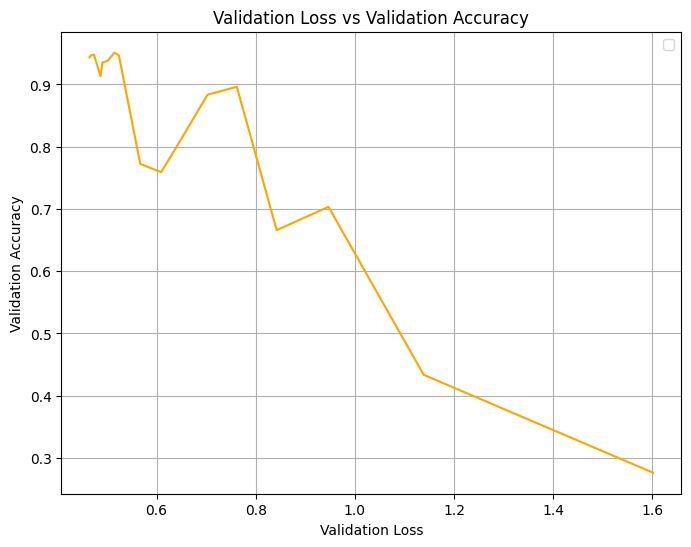

In [ ]:
# Plot: Train loss vs Train accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], history.history['accuracy'], color='green')
plt.xlabel('Train Loss')
plt.ylabel('Train Accuracy')
plt.title('Train Loss vs Train Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("train_loss_vs_train_accuracy.png")
plt.show()

# Plot: val loss vs Val accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], history.history['val_accuracy'], color='orange')
plt.xlabel('Validation Loss')
plt.ylabel('Validation Accuracy')
plt.title('Validation Loss vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("val_acc_vs_val_loss.png")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

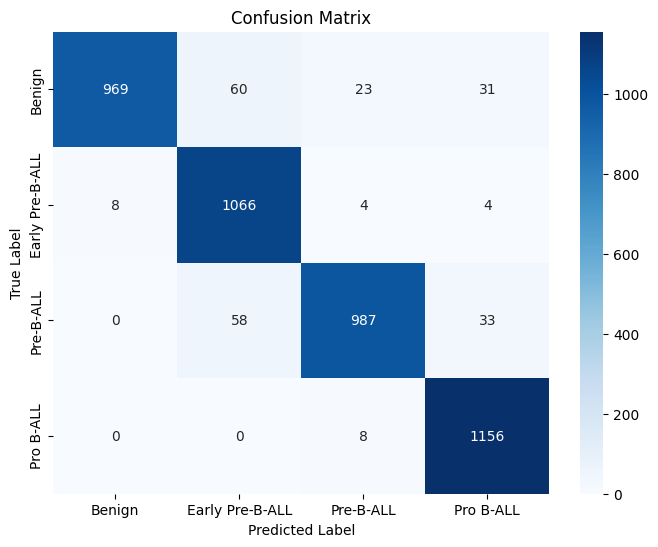

Classification Report:
               precision    recall  f1-score   support

  all_benign       0.99      0.89      0.94      1083
   all_early       0.90      0.99      0.94      1082
     all_pre       0.97      0.92      0.94      1078
     all_pro       0.94      0.99      0.97      1164

    accuracy                           0.95      4407
   macro avg       0.95      0.95      0.95      4407
weighted avg       0.95      0.95      0.95      4407

Classification Report:

                 precision    recall  f1-score   support

         Benign     0.9918    0.8947    0.9408      1083
Early Pre-B-ALL     0.9003    0.9852    0.9409      1082
      Pre-B-ALL     0.9658    0.9156    0.9400      1078
      Pro B-ALL     0.9444    0.9931    0.9682      1164

       accuracy                         0.9480      4407
      macro avg     0.9506    0.9472    0.9475      4407
   weighted avg     0.9505    0.9480    0.9478      4407



<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# class in tf_flowers
class_name = ['all_benign', 'all_early', 'all_pre', 'all_pro']

# Get true labels and predictions
y_true = []
y_pred = []


for images, labels in val_ds:
    predictions = model.predict(images)  # Get predicted probabilities
    y_true.extend(labels.numpy())  # Store true labels
    y_pred.extend(np.argmax(predictions,axis=1))  # Convert probs to class labels using argmax
# grabs the index of the class with highest probability, for each image.

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred) #compares predictions vs. true labels.

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names = class_name))
#classification_report() — gives precision, recall, and F1-score per class

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
plt.savefig("confusion_matrix.png")
print(report)


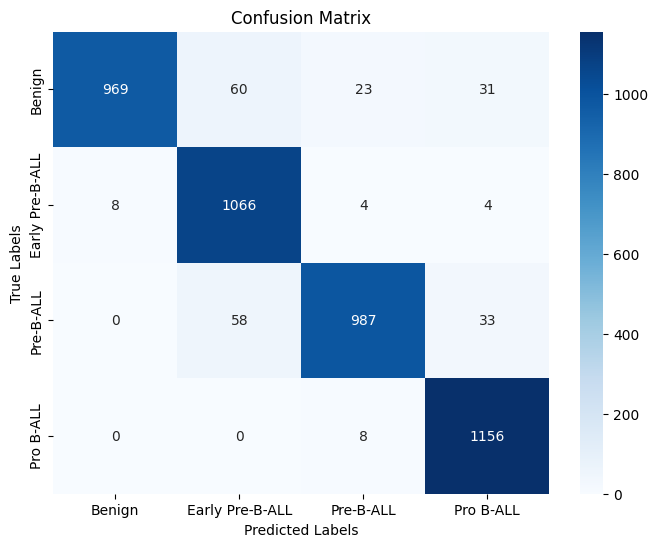

Classification Report:

                 precision    recall  f1-score   support

         Benign     0.9918    0.8947    0.9408      1083
Early Pre-B-ALL     0.9003    0.9852    0.9409      1082
      Pre-B-ALL     0.9658    0.9156    0.9400      1078
      Pro B-ALL     0.9444    0.9931    0.9682      1164

       accuracy                         0.9480      4407
      macro avg     0.9506    0.9472    0.9475      4407
   weighted avg     0.9505    0.9480    0.9478      4407



<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions from the validation set
y_true = []
y_pred = []

for images, labels in val_ds.unbatch():
    y_true.append(int(labels.numpy()))
    preds = model.predict(tf.expand_dims(images, axis=0), verbose=0)
    y_pred.append(np.argmax(preds))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
plt.savefig("confusion_matrix.png")
print(report)


In [ ]:
# Print precision, recall, f1-score, support
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
print(report)

# Optional: Save report to .txt file
with open("classification_report.txt", "w") as f:
    f.write(report)


Classification Report:

                 precision    recall  f1-score   support

         Benign     0.9918    0.8947    0.9408      1083
Early Pre-B-ALL     0.9003    0.9852    0.9409      1082
      Pre-B-ALL     0.9658    0.9156    0.9400      1078
      Pro B-ALL     0.9444    0.9931    0.9682      1164

       accuracy                         0.9480      4407
      macro avg     0.9506    0.9472    0.9475      4407
   weighted avg     0.9505    0.9480    0.9478      4407

